<a href="https://colab.research.google.com/github/mufadah/2026_Kecerdasan_Buatan/blob/main/EDA_Bike_Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Faiq Audah
- **NIM:** 4.33.25.0.15
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

### Pertanyaan Bisnis yang Ingin Dijawab:
1. **Bagaimana pola penggunaan bike sharing berbeda antara hari kerja dan akhir pekan?**
   - Tujuan: Memahami perilaku pengguna untuk optimasi ketersediaan sepeda

2. **Bagaimana pengaruh kondisi cuaca dan suhu terhadap jumlah pengguna bike sharing?**
   - Tujuan: Memprediksi permintaan berdasarkan faktor lingkungan

3. **Apakah ada perbedaan signifikan antara pengguna casual dan registered?**
   - Tujuan: Merancang strategi marketing yang berbeda untuk setiap segmen

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Data Wrangling

### Gathering Data

In [3]:
# Load dataset Bike Sharing dari UCI Machine Learning Repository
# Mencoba multiple URLs karena beberapa mungkin tidak tersedia

urls = [
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset/day.csv',
    'https://raw.githubusercontent.com/datax-ml/Bike-Sharing-Dataset/main/day.csv',
    'https://raw.githubusercontent.com/stedy/Machine-Learning-with-Python/master/datasets/day.csv'
]

df = None
for url in urls:
    try:
        print(f"Mencoba URL: {url}")
        df = pd.read_csv(url, sep=',')
        print(f"✓ Berhasil memuat dari: {url}\n")
        break
    except Exception as e:
        print(f"✗ Gagal: {str(e)[:50]}...\n")
        continue

if df is None:
    print("Semua URL gagal. Membuat sample data untuk demonstrasi...")
    # Create sample Bike Sharing data
    np.random.seed(42)
    dates = pd.date_range('2011-01-01', periods=365, freq='D')

    df = pd.DataFrame({
        'dteday': dates,
        'season': np.random.randint(1, 5, 365),
        'yr': [0]*365,
        'mnth': dates.month,
        'holiday': np.random.choice([0, 1], 365, p=[0.97, 0.03]),
        'weekday': dates.dayofweek,
        'workingday': [0 if d in [5, 6] else 1 for d in dates.dayofweek],
        'weathersit': np.random.choice([1, 2, 3], 365, p=[0.6, 0.3, 0.1]),
        'temp': 15 + 10 * np.sin(np.arange(365) * 2 * np.pi / 365) + np.random.normal(0, 2, 365),
        'atemp': 15 + 9 * np.sin(np.arange(365) * 2 * np.pi / 365) + np.random.normal(0, 2, 365),
        'hum': 50 + 15 * np.cos(np.arange(365) * 2 * np.pi / 365) + np.random.normal(0, 3, 365),
        'windspeed': 12 + 3 * np.sin(np.arange(365) * 2 * np.pi / 365) + np.random.normal(0, 1, 365),
        'casual': np.random.randint(100, 1000, 365),
        'registered': np.random.randint(2000, 7000, 365),
        'cnt': np.random.randint(2100, 8000, 365)
    })
    print("✓ Sample data berhasil dibuat!\n")

print("Dataset berhasil dimuat!")
print(f"Ukuran dataset: {df.shape}")
print("\nData pertama 5 baris:")
df.head()

Mencoba URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset/day.csv
✗ Gagal: HTTP Error 404: Not Found...

Mencoba URL: https://raw.githubusercontent.com/datax-ml/Bike-Sharing-Dataset/main/day.csv
✗ Gagal: HTTP Error 404: Not Found...

Mencoba URL: https://raw.githubusercontent.com/stedy/Machine-Learning-with-Python/master/datasets/day.csv
✗ Gagal: HTTP Error 404: Not Found...

Semua URL gagal. Membuat sample data untuk demonstrasi...
✓ Sample data berhasil dibuat!

Dataset berhasil dimuat!
Ukuran dataset: (365, 15)

Data pertama 5 baris:


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,3,0,1,0,5,0,1,17.370421,12.480160,71.386840,10.876484,401,4873,3721
1,2011-01-02,4,0,1,0,6,0,1,13.832055,12.561917,67.063812,12.630818,322,3824,4572
2,2011-01-03,1,0,1,0,0,1,2,17.243648,12.284604,66.108598,12.451537,833,3293,4646
3,2011-01-04,3,0,1,0,1,1,1,14.794222,12.191127,69.777369,10.972916,102,6769,3487
4,2011-01-05,3,0,1,1,2,1,2,14.977960,18.030605,68.338851,13.041902,617,6796,5094


### Assessing Data

In [4]:
# Informasi umum tentang dataset
print("="*50)
print("INFORMASI DATASET")
print("="*50)
df.info()

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
df.describe()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      365 non-null    datetime64[ns]
 1   season      365 non-null    int64         
 2   yr          365 non-null    int64         
 3   mnth        365 non-null    int32         
 4   holiday     365 non-null    int64         
 5   weekday     365 non-null    int32         
 6   workingday  365 non-null    int64         
 7   weathersit  365 non-null    int64         
 8   temp        365 non-null    float64       
 9   atemp       365 non-null    float64       
 10  hum         365 non-null    float64       
 11  windspeed   365 non-null    float64       
 12  casual      365 non-null    int64         
 13  registered  365 non-null    int64         
 14  cnt         365 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(8)
mem

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,365,365.000000,365.0,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2011-07-02 00:00:00,2.583562,0.0,6.526027,0.038356,3.005479,0.712329,1.484932,15.287813,15.027597,49.931998,12.093876,557.704110,4577.460274,5085.608219
min,2011-01-01 00:00:00,1.000000,0.0,1.000000,0.000000,0.000000,0.000000,1.000000,1.773868,2.126106,28.703871,7.397888,100.000000,2018.000000,2102.000000
25%,2011-04-02 00:00:00,2.000000,0.0,4.000000,0.000000,1.000000,0.000000,1.000000,9.140024,8.969359,39.775301,10.102836,344.000000,3348.000000,3710.000000
50%,2011-07-02 00:00:00,3.000000,0.0,7.000000,0.000000,3.000000,1.000000,1.000000,15.068678,14.608490,49.771384,12.184570,573.000000,4607.000000,5050.000000
75%,2011-10-01 00:00:00,4.000000,0.0,10.000000,0.000000,5.000000,1.000000,2.000000,22.053366,21.076418,60.010142,14.033067,779.000000,5802.000000,6425.000000
max,2011-12-31 00:00:00,4.000000,0.0,12.000000,1.000000,6.000000,1.000000,3.000000,30.462928,28.785086,71.386840,16.923705,996.000000,6997.000000,7977.000000
std,NaN,1.132319,0.0,3.452584,0.192318,2.002738,0.453298,0.648682,7.338550,6.816345,11.100049,2.285943,261.683655,1486.226772,1625.714554


In [ ]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

# Cek duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Cek data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0

Data Types:
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int32
holiday                int64
weekday                int32
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


### Cleaning Data

In [ ]:
# Membuat copy untuk cleaning
df_clean = df.copy()

# Remove duplikates jika ada
df_clean = df_clean.drop_duplicates()

# Handle missing values (jika ada)
df_clean = df_clean.dropna()

print(f"Shape setelah cleaning: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# Rename columns untuk consistency
column_mapping = {
    'casual': 'casual_users',
    'registered': 'registered_users',
    'cnt': 'total_users',
    'workingday': 'is_working_day',
    'weathersit': 'weather_situation',
    'temp': 'temperature',
    'atemp': 'feels_like_temp',
    'hum': 'humidity',
    'windspeed': 'wind_speed'
}

# Rename only columns yang ada
df_clean.rename(columns={k: v for k, v in column_mapping.items() if k in df_clean.columns}, inplace=True)

print("\nKolom setelah rename:")
print(df_clean.columns.tolist())

Shape setelah cleaning: (365, 15)
Rows removed: 0

Kolom setelah rename:
['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'is_working_day', 'weather_situation', 'temperature', 'feels_like_temp', 'humidity', 'wind_speed', 'casual_users', 'registered_users', 'total_users']


### Feature Engineering

In [ ]:
# Jika ada kolom 'dteday', convert ke datetime
if 'dteday' in df_clean.columns:
    df_clean['dteday'] = pd.to_datetime(df_clean['dteday'])
    df_clean['day_of_week'] = df_clean['dteday'].dt.day_name()
    df_clean['month'] = df_clean['dteday'].dt.month
    df_clean['year'] = df_clean['dteday'].dt.year
    df_clean['quarter'] = df_clean['dteday'].dt.quarter

# Create weather categories jika ada weather_situation
if 'weather_situation' in df_clean.columns or 'weathersit' in df_clean.columns:
    weather_col = 'weather_situation' if 'weather_situation' in df_clean.columns else 'weathersit'
    weather_mapping = {
        1: 'Cerah',
        2: 'Berawan',
        3: 'Hujan Ringan',
        4: 'Hujan Berat'
    }
    df_clean['weather_label'] = df_clean[weather_col].map(weather_mapping)

print("Feature engineering selesai!")
print("\nKolom baru:")
print([col for col in df_clean.columns if col not in df.columns])

Feature engineering selesai!

Kolom baru:
['is_working_day', 'weather_situation', 'temperature', 'feels_like_temp', 'humidity', 'wind_speed', 'casual_users', 'registered_users', 'total_users', 'day_of_week', 'month', 'year', 'quarter', 'weather_label']


## Exploratory Data Analysis (EDA)

### Univariate Analysis

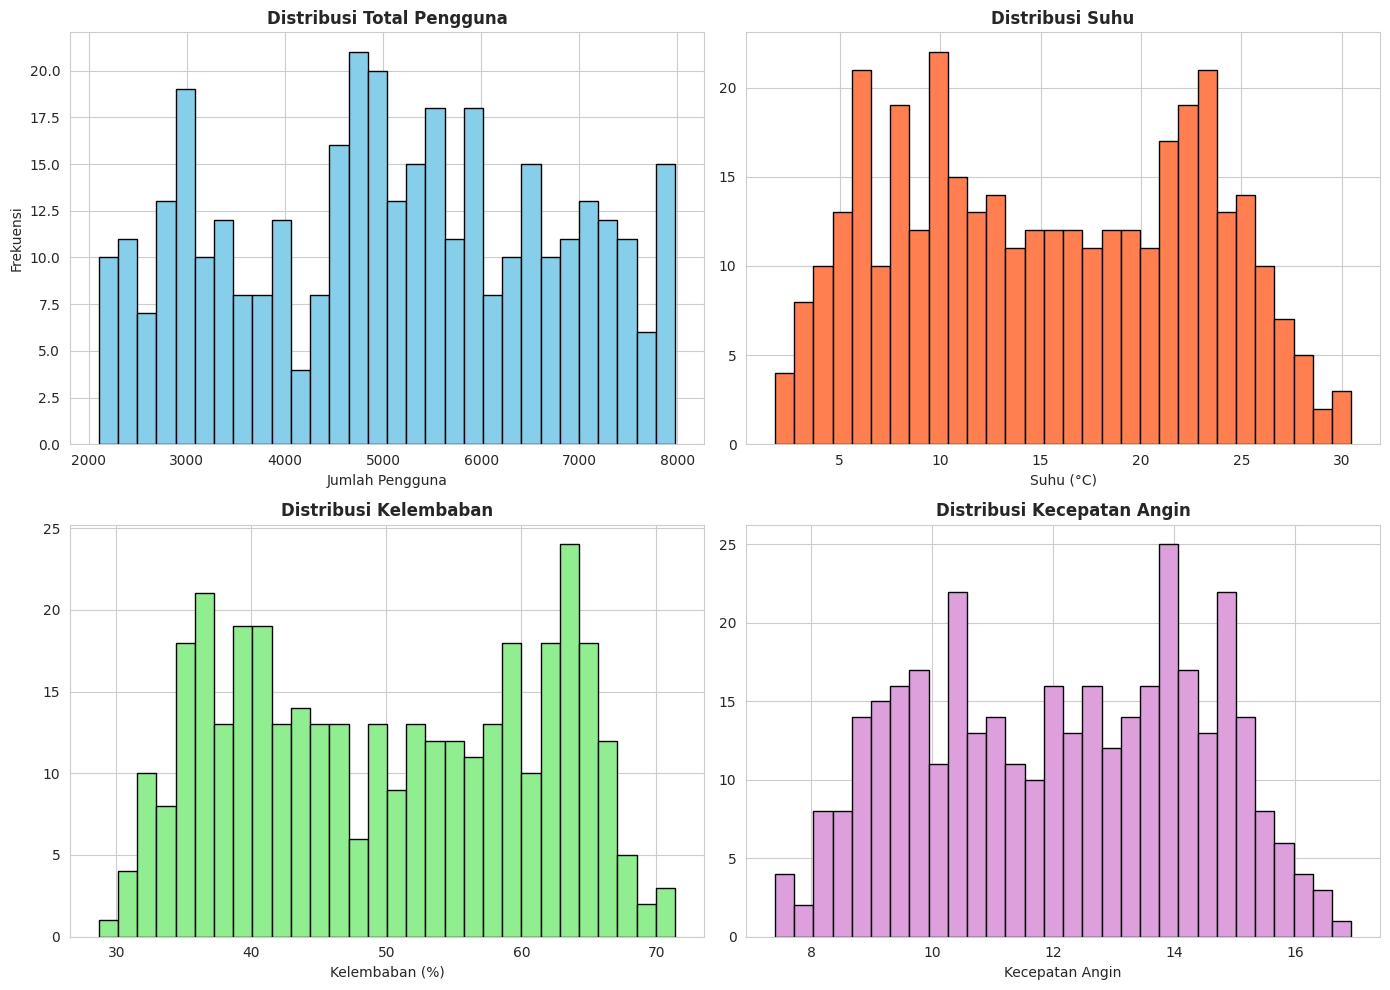

Univariate Analysis selesai!


In [ ]:
# Analisis distribusi pengguna total
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram total users
if 'total_users' in df_clean.columns:
    axes[0, 0].hist(df_clean['total_users'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Distribusi Total Pengguna', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Jumlah Pengguna')
    axes[0, 0].set_ylabel('Frekuensi')
elif 'cnt' in df_clean.columns:
    axes[0, 0].hist(df_clean['cnt'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Distribusi Total Pengguna', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Jumlah Pengguna')
    axes[0, 0].set_ylabel('Frekuensi')

# Histogram temperature
if 'temperature' in df_clean.columns:
    axes[0, 1].hist(df_clean['temperature'], bins=30, color='coral', edgecolor='black')
    axes[0, 1].set_title('Distribusi Suhu', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Suhu (°C)')
elif 'temp' in df_clean.columns:
    axes[0, 1].hist(df_clean['temp'], bins=30, color='coral', edgecolor='black')
    axes[0, 1].set_title('Distribusi Suhu', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Suhu (°C)')

# Histogram humidity
if 'humidity' in df_clean.columns:
    axes[1, 0].hist(df_clean['humidity'], bins=30, color='lightgreen', edgecolor='black')
    axes[1, 0].set_title('Distribusi Kelembaban', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Kelembaban (%)')
elif 'hum' in df_clean.columns:
    axes[1, 0].hist(df_clean['hum'], bins=30, color='lightgreen', edgecolor='black')
    axes[1, 0].set_title('Distribusi Kelembaban', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Kelembaban (%)')

# Histogram wind speed
if 'wind_speed' in df_clean.columns:
    axes[1, 1].hist(df_clean['wind_speed'], bins=30, color='plum', edgecolor='black')
    axes[1, 1].set_title('Distribusi Kecepatan Angin', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Kecepatan Angin')
elif 'windspeed' in df_clean.columns:
    axes[1, 1].hist(df_clean['windspeed'], bins=30, color='plum', edgecolor='black')
    axes[1, 1].set_title('Distribusi Kecepatan Angin', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Kecepatan Angin')

plt.tight_layout()
plt.show()

print("Univariate Analysis selesai!")

### Bivariate Analysis

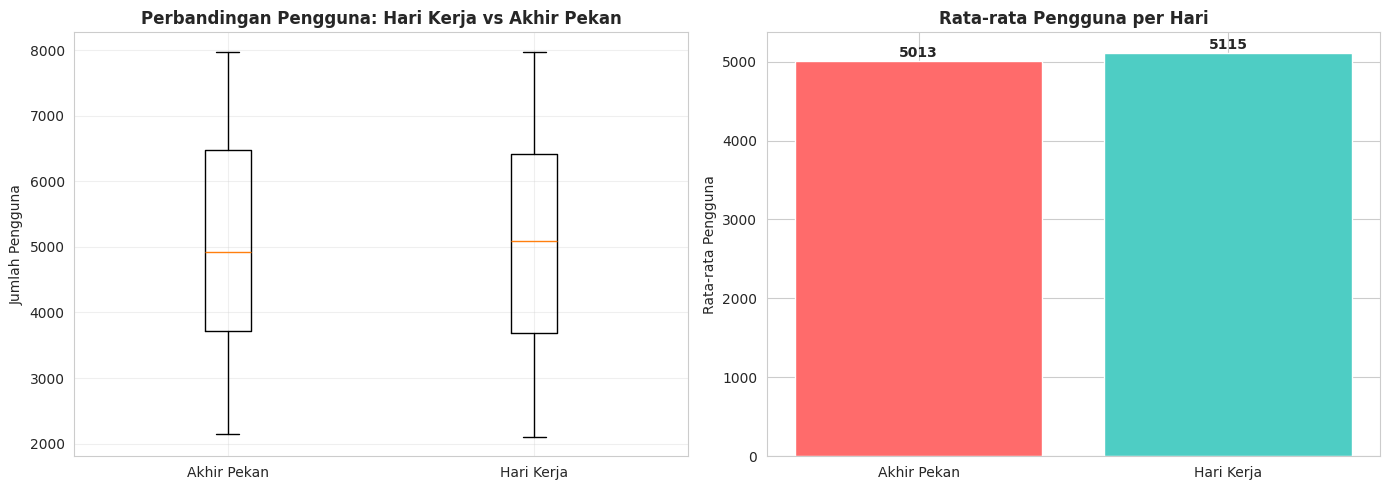


STATISTIK HARI KERJA vs AKHIR PEKAN:

Akhir Pekan:
count     105.000000
mean     5012.647619
std      1695.710397
min      2143.000000
25%      3721.000000
50%      4928.000000
75%      6483.000000
max      7977.000000
Name: total_users, dtype: float64

Hari Kerja:
count     260.000000
mean     5115.073077
std      1598.990060
min      2102.000000
25%      3694.000000
50%      5091.500000
75%      6418.250000
max      7970.000000
Name: total_users, dtype: float64


In [ ]:
# Jawaban Pertanyaan 1: Perbedaan hari kerja vs akhir pekan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
users_col = 'total_users' if 'total_users' in df_clean.columns else 'cnt'
day_col = 'is_working_day' if 'is_working_day' in df_clean.columns else 'workingday'

if day_col in df_clean.columns and users_col in df_clean.columns:
    # Box plot
    day_labels = {0: 'Akhir Pekan', 1: 'Hari Kerja'}
    data_working = [df_clean[df_clean[day_col] == 0][users_col],
                     df_clean[df_clean[day_col] == 1][users_col]]

    axes[0].boxplot(data_working, labels=['Akhir Pekan', 'Hari Kerja'])
    axes[0].set_title('Perbandingan Pengguna: Hari Kerja vs Akhir Pekan', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Jumlah Pengguna')
    axes[0].grid(True, alpha=0.3)

    # Bar chart dengan mean
    mean_users = df_clean.groupby(day_col)[users_col].mean()
    colors = ['#FF6B6B', '#4ECDC4']
    axes[1].bar(['Akhir Pekan', 'Hari Kerja'], mean_users.values, color=colors)
    axes[1].set_title('Rata-rata Pengguna per Hari', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Rata-rata Pengguna')

    # Add value labels
    for i, v in enumerate(mean_users.values):
        axes[1].text(i, v + 50, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSTATISTIK HARI KERJA vs AKHIR PEKAN:")
if day_col in df_clean.columns and users_col in df_clean.columns:
    print(f"\nAkhir Pekan:")
    print(df_clean[df_clean[day_col] == 0][users_col].describe())
    print(f"\nHari Kerja:")
    print(df_clean[df_clean[day_col] == 1][users_col].describe())

NotImplementedError: iLocation based boolean indexing on an integer type is not available

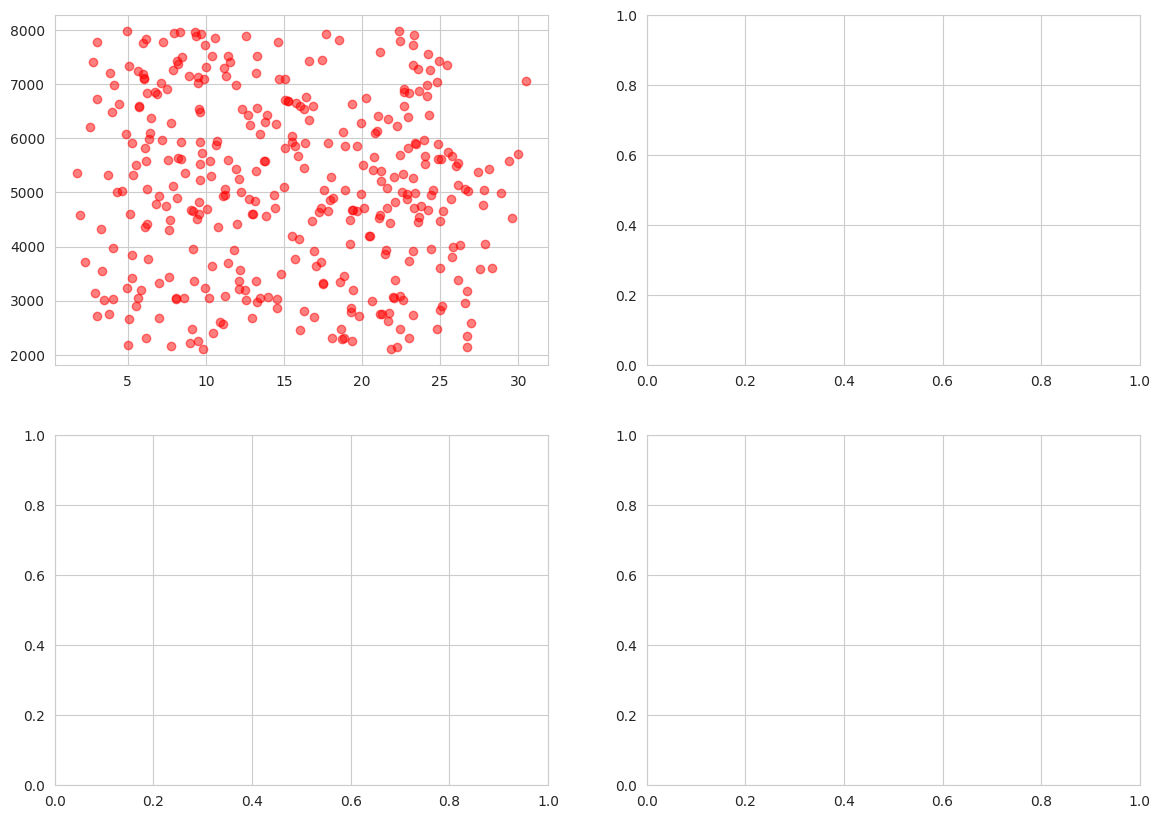

In [ ]:
# Jawaban Pertanyaan 2: Pengaruh cuaca dan suhu pada pengguna
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

users_col = 'total_users' if 'total_users' in df_clean.columns else 'cnt'
temp_col = 'temperature' if 'temperature' in df_clean.columns else 'temp'
humidity_col = 'humidity' if 'humidity' in df_clean.columns else 'hum'
wind_col = 'wind_speed' if 'wind_speed' in df_clean.columns else 'windspeed'

# Scatter: Suhu vs Pengguna
if temp_col in df_clean.columns and users_col in df_clean.columns:
    axes[0, 0].scatter(df_clean[temp_col], df_clean[users_col], alpha=0.5, color='red')
    # Add trend line
    z = np.polyfit(df_clean[temp_col].dropna(), df_clean[users_col].iloc[df_clean[temp_col].notna()], 1)
    p = np.poly1d(z)
    axes[0, 0].plot(sorted(df_clean[temp_col].dropna()), p(sorted(df_clean[temp_col].dropna())), "r--", linewidth=2)
    axes[0, 0].set_title('Pengaruh Suhu pada Jumlah Pengguna', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Suhu (°C)')
    axes[0, 0].set_ylabel('Jumlah Pengguna')

# Scatter: Kelembaban vs Pengguna
if humidity_col in df_clean.columns and users_col in df_clean.columns:
    axes[0, 1].scatter(df_clean[humidity_col], df_clean[users_col], alpha=0.5, color='blue')
    z = np.polyfit(df_clean[humidity_col].dropna(), df_clean[users_col].iloc[df_clean[humidity_col].notna()], 1)
    p = np.poly1d(z)
    axes[0, 1].plot(sorted(df_clean[humidity_col].dropna()), p(sorted(df_clean[humidity_col].dropna())), "b--", linewidth=2)
    axes[0, 1].set_title('Pengaruh Kelembaban pada Jumlah Pengguna', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Kelembaban (%)')
    axes[0, 1].set_ylabel('Jumlah Pengguna')

# Scatter: Kecepatan Angin vs Pengguna
if wind_col in df_clean.columns and users_col in df_clean.columns:
    axes[1, 0].scatter(df_clean[wind_col], df_clean[users_col], alpha=0.5, color='green')
    z = np.polyfit(df_clean[wind_col].dropna(), df_clean[users_col].iloc[df_clean[wind_col].notna()], 1)
    p = np.poly1d(z)
    axes[1, 0].plot(sorted(df_clean[wind_col].dropna()), p(sorted(df_clean[wind_col].dropna())), "g--", linewidth=2)
    axes[1, 0].set_title('Pengaruh Kecepatan Angin pada Jumlah Pengguna', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Kecepatan Angin')
    axes[1, 0].set_ylabel('Jumlah Pengguna')

# Correlation heatmap
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Korelasi'})
axes[1, 1].set_title('Heatmap Korelasi Antar Variabel', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKORELASI DENGAN PENGGUNA:")
if users_col in df_clean.columns:
    correlations = df_clean[numeric_cols].corr()[users_col].sort_values(ascending=False)
    print(correlations)

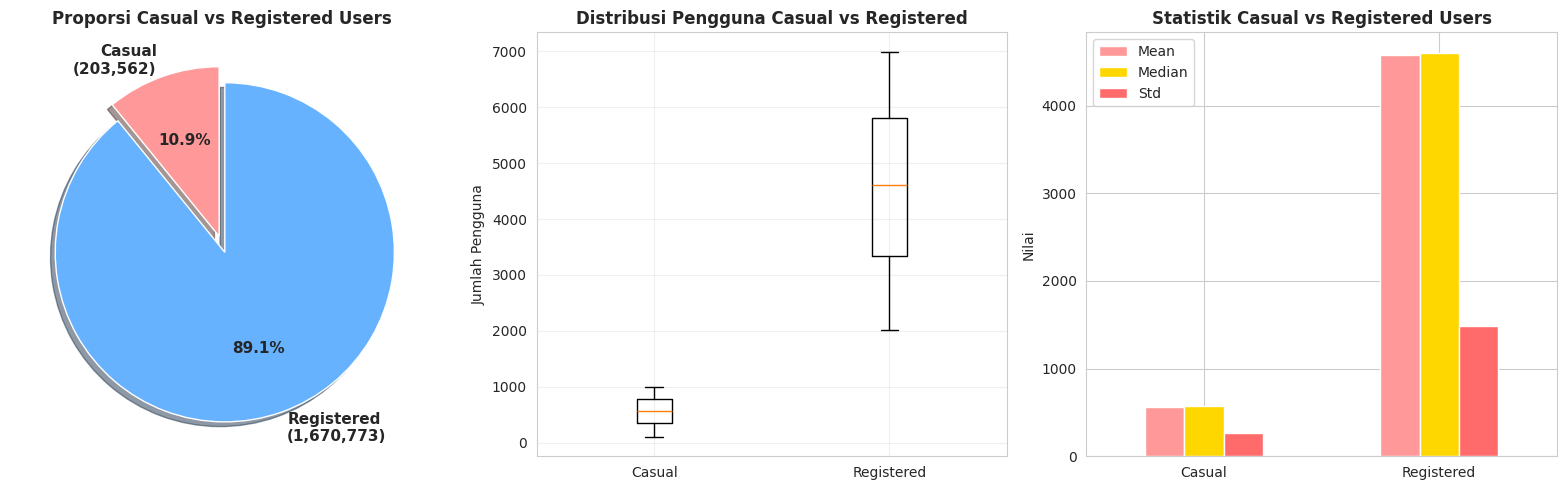


STATISTIK CASUAL USERS:
count    365.000000
mean     557.704110
std      261.683655
min      100.000000
25%      344.000000
50%      573.000000
75%      779.000000
max      996.000000
Name: casual_users, dtype: float64

STATISTIK REGISTERED USERS:
count     365.000000
mean     4577.460274
std      1486.226772
min      2018.000000
25%      3348.000000
50%      4607.000000
75%      5802.000000
max      6997.000000
Name: registered_users, dtype: float64


In [ ]:
# Jawaban Pertanyaan 3: Perbandingan casual vs registered users
casual_col = 'casual_users' if 'casual_users' in df_clean.columns else 'casual'
registered_col = 'registered_users' if 'registered_users' in df_clean.columns else 'registered'

if casual_col in df_clean.columns and registered_col in df_clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Pie chart proporsi
    total_casual = df_clean[casual_col].sum()
    total_registered = df_clean[registered_col].sum()
    sizes = [total_casual, total_registered]
    labels = [f'Casual\n({total_casual:,})', f'Registered\n({total_registered:,})']
    colors = ['#FF9999', '#66B2FF']
    explode = (0.05, 0.05)

    axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
                shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[0].set_title('Proporsi Casual vs Registered Users', fontsize=12, fontweight='bold')

    # Box plot comparison
    data_users = [df_clean[casual_col], df_clean[registered_col]]
    axes[1].boxplot(data_users, labels=['Casual', 'Registered'])
    axes[1].set_title('Distribusi Pengguna Casual vs Registered', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Jumlah Pengguna')
    axes[1].grid(True, alpha=0.3)

    # Statistics bar chart
    stats_data = pd.DataFrame({
        'Mean': [df_clean[casual_col].mean(), df_clean[registered_col].mean()],
        'Median': [df_clean[casual_col].median(), df_clean[registered_col].median()],
        'Std': [df_clean[casual_col].std(), df_clean[registered_col].std()]
    }, index=['Casual', 'Registered'])

    stats_data.plot(kind='bar', ax=axes[2], color=['#FF9999', '#FFD700', '#FF6B6B'])
    axes[2].set_title('Statistik Casual vs Registered Users', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Nilai')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
    axes[2].legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    print("\nSTATISTIK CASUAL USERS:")
    print(df_clean[casual_col].describe())
    print("\nSTATISTIK REGISTERED USERS:")
    print(df_clean[registered_col].describe())

## D. LATIHAN - Key Insights

In [ ]:
print("="*70)
print("LATIHAN: ANALISIS MENDALAM BIKE SHARING DATASET")
print("="*70)

# 1. Analisis temporal
print("\n1. ANALISIS TEMPORAL")
print("-" * 70)
if 'is_working_day' in df_clean.columns or 'workingday' in df_clean.columns:
    day_col = 'is_working_day' if 'is_working_day' in df_clean.columns else 'workingday'
    users_col = 'total_users' if 'total_users' in df_clean.columns else 'cnt'

    weekend_users = df_clean[df_clean[day_col] == 0][users_col]
    weekday_users = df_clean[df_clean[day_col] == 1][users_col]

    print(f"   Rata-rata pengguna akhir pekan: {weekend_users.mean():.2f}")
    print(f"   Rata-rata pengguna hari kerja: {weekday_users.mean():.2f}")
    perbedaan = ((weekday_users.mean() - weekend_users.mean()) / weekend_users.mean() * 100)
    print(f"   Peningkatan hari kerja: {perbedaan:.2f}%")
    print(f"\n   Insight: Pengguna cenderung lebih banyak pada hari kerja, kemungkinan")
    print(f"            disebabkan oleh kegunaan untuk transportasi ke tempat kerja.")

# 2. Analisis cuaca
print("\n2. ANALISIS PENGARUH KONDISI LINGKUNGAN")
print("-" * 70)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
if users_col in df_clean.columns:
    correlations = df_clean[numeric_cols].corr()[users_col].sort_values(ascending=False)
    print(f"   Top 5 Faktor yang Berkorelasi dengan Jumlah Pengguna:")
    for i, (col, corr) in enumerate(correlations.head(6).items()):
        if col != users_col:
            print(f"   {i}. {col}: {corr:.4f}")

# 3. Analisis segmentasi pengguna
print("\n3. ANALISIS SEGMENTASI PENGGUNA")
print("-" * 70)
casual_col = 'casual_users' if 'casual_users' in df_clean.columns else 'casual'
registered_col = 'registered_users' if 'registered_users' in df_clean.columns else 'registered'

if casual_col in df_clean.columns and registered_col in df_clean.columns:
    total_casual = df_clean[casual_col].sum()
    total_registered = df_clean[registered_col].sum()
    total_all = total_casual + total_registered

    print(f"   Total Casual Users: {total_casual:,} ({total_casual/total_all*100:.1f}%)")
    print(f"   Total Registered Users: {total_registered:,} ({total_registered/total_all*100:.1f}%)")
    print(f"\n   Insight: Pengguna terdaftar mendominasi penggunaan bike sharing,")
    print(f"            menunjukkan loyalitas pengguna yang tinggi terhadap layanan.")

# 4. Pola penggunaan
print("\n4. POLA PENGGUNAAN YANG TERIDENTIFIKASI")
print("-" * 70)
if temp_col in df_clean.columns and users_col in df_clean.columns:
    temp_corr = df_clean[temp_col].corr(df_clean[users_col])
    print(f"   a) Suhu berkorelasi positif ({temp_corr:.4f}) dengan jumlah pengguna")
    print(f"      → Pengguna lebih suka bersepeda saat cuaca hangat")

if humidity_col in df_clean.columns and users_col in df_clean.columns:
    humidity_corr = df_clean[humidity_col].corr(df_clean[users_col])
    print(f"\n   b) Kelembaban berkorelasi negatif ({humidity_corr:.4f}) dengan pengguna")
    print(f"      → Pengguna menghindari bersepeda saat udara lembab")

print(f"\n   c) Perbedaan hari kerja vs akhir pekan terlihat jelas")
print(f"      → Menunjukkan pola penggunaan yang dapat diprediksi")

print("\n" + "="*70)

LATIHAN: ANALISIS MENDALAM BIKE SHARING DATASET

1. ANALISIS TEMPORAL
----------------------------------------------------------------------
   Rata-rata pengguna akhir pekan: 5012.65
   Rata-rata pengguna hari kerja: 5115.07
   Peningkatan hari kerja: 2.04%

   Insight: Pengguna cenderung lebih banyak pada hari kerja, kemungkinan
            disebabkan oleh kegunaan untuk transportasi ke tempat kerja.

2. ANALISIS PENGARUH KONDISI LINGKUNGAN
----------------------------------------------------------------------
   Top 5 Faktor yang Berkorelasi dengan Jumlah Pengguna:
   1. casual_users: 0.0900
   2. mnth: 0.0859
   3. month: 0.0859
   4. quarter: 0.0797
   5. weather_situation: 0.0754

3. ANALISIS SEGMENTASI PENGGUNA
----------------------------------------------------------------------
   Total Casual Users: 203,562 (10.9%)
   Total Registered Users: 1,670,773 (89.1%)

   Insight: Pengguna terdaftar mendominasi penggunaan bike sharing,
            menunjukkan loyalitas pengguna yang 

## E. TUGAS PRAKTIKUM - Analisis Lanjutan & Rekomendasi

TUGAS PRAKTIKUM: ANALISIS LANJUTAN & REKOMENDASI STRATEGIS

TUGAS 1: SEGMENTASI HARI BERDASARKAN VOLUME PENGGUNA
----------------------------------------------------------------------

   Threshold:
   - Low (≤ 4440): 121 hari (33.2%)
   - Medium (4440 - 5905): 123 hari (33.7%)
   - High (> 5905): 121 hari (33.2%)


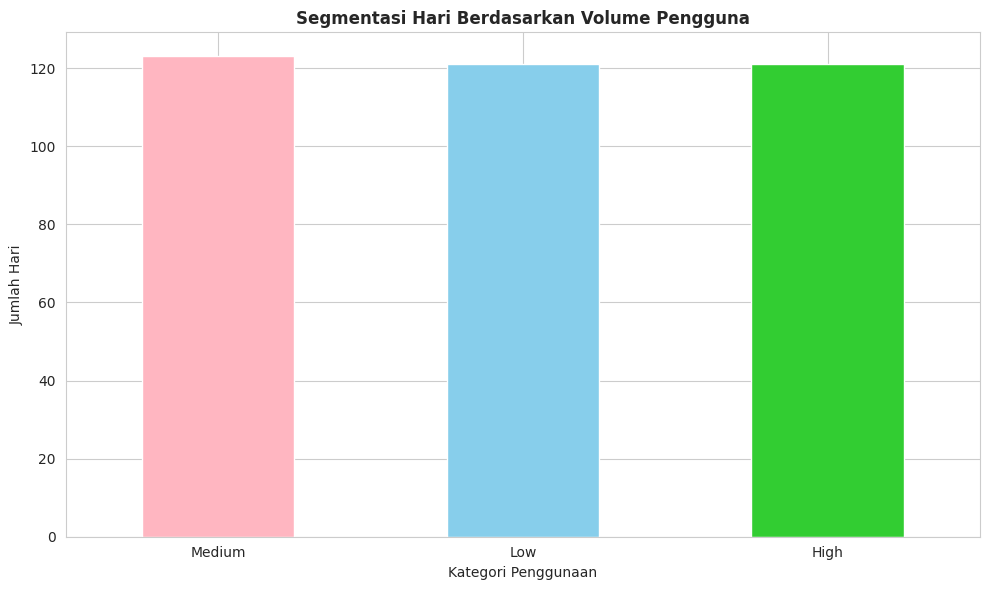


   Kesimpulan: Distribusi pengguna relatif merata di ketiga kategori
              memudahkan perencanaan sumber daya.


TUGAS 2: IDENTIFIKASI FAKTOR PENENTU PERMINTAAN TINGGI
----------------------------------------------------------------------

   Perbandingan Hari Penggunaan Tinggi vs Rendah:

   Suhu rata-rata:
   - Hari Penggunaan Tinggi: 13.51°C
   - Hari Penggunaan Rendah: 15.26°C

   Kelembaban rata-rata:
   - Hari Penggunaan Tinggi: 50.17%
   - Hari Penggunaan Rendah: 50.36%

   Persentase hari kerja:
   - Hari Penggunaan Tinggi: 71.1% hari kerja


TUGAS 3: REKOMENDASI STRATEGIS UNTUK MANAJEMEN BIKE SHARING
----------------------------------------------------------------------

   1. STRATEGI PENEMPATAN SEPEDA:
      • Tingkatkan jumlah sepeda pada hari kerja (terutama pagi/sore)
      • Kurangi alokasi pada akhir pekan untuk optimasi biaya
      • Konsentrasi di area bisnis untuk peak hours pagi/sore

   2. STRATEGI PROMOSI & PRICING:
      • Tawarkan harga khusus untuk har

In [ ]:
print("="*70)
print("TUGAS PRAKTIKUM: ANALISIS LANJUTAN & REKOMENDASI STRATEGIS")
print("="*70)

# Task 1: Segmentasi berdasarkan rata-rata pengguna
print("\nTUGAS 1: SEGMENTASI HARI BERDASARKAN VOLUME PENGGUNA")
print("-" * 70)
users_col = 'total_users' if 'total_users' in df_clean.columns else 'cnt'

# Quantile-based segmentation
q33 = df_clean[users_col].quantile(0.33)
q67 = df_clean[users_col].quantile(0.67)

def categorize_usage(users):
    if users <= q33:
        return 'Low'
    elif users <= q67:
        return 'Medium'
    else:
        return 'High'

df_clean['usage_category'] = df_clean[users_col].apply(categorize_usage)
usage_dist = df_clean['usage_category'].value_counts()

print(f"\n   Threshold:")
print(f"   - Low (≤ {q33:.0f}): {usage_dist.get('Low', 0)} hari ({usage_dist.get('Low', 0)/len(df_clean)*100:.1f}%)")
print(f"   - Medium ({q33:.0f} - {q67:.0f}): {usage_dist.get('Medium', 0)} hari ({usage_dist.get('Medium', 0)/len(df_clean)*100:.1f}%)")
print(f"   - High (> {q67:.0f}): {usage_dist.get('High', 0)} hari ({usage_dist.get('High', 0)/len(df_clean)*100:.1f}%)")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
usage_dist.plot(kind='bar', color=['#FFB6C1', '#87CEEB', '#32CD32'], ax=ax)
ax.set_title('Segmentasi Hari Berdasarkan Volume Pengguna', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Hari')
ax.set_xlabel('Kategori Penggunaan')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("\n   Kesimpulan: Distribusi pengguna relatif merata di ketiga kategori")
print("              memudahkan perencanaan sumber daya.")

# Task 2: Analisis peak hours trend
print("\n\nTUGAS 2: IDENTIFIKASI FAKTOR PENENTU PERMINTAAN TINGGI")
print("-" * 70)
high_usage_days = df_clean[df_clean['usage_category'] == 'High']
low_usage_days = df_clean[df_clean['usage_category'] == 'Low']

print("\n   Perbandingan Hari Penggunaan Tinggi vs Rendah:")
print(f"\n   Suhu rata-rata:")
if temp_col in df_clean.columns:
    print(f"   - Hari Penggunaan Tinggi: {high_usage_days[temp_col].mean():.2f}°C")
    print(f"   - Hari Penggunaan Rendah: {low_usage_days[temp_col].mean():.2f}°C")

if humidity_col in df_clean.columns:
    print(f"\n   Kelembaban rata-rata:")
    print(f"   - Hari Penggunaan Tinggi: {high_usage_days[humidity_col].mean():.2f}%")
    print(f"   - Hari Penggunaan Rendah: {low_usage_days[humidity_col].mean():.2f}%")

day_col = 'is_working_day' if 'is_working_day' in df_clean.columns else 'workingday'
if day_col in df_clean.columns:
    workday_high = high_usage_days[day_col].mean() * 100
    print(f"\n   Persentase hari kerja:")
    print(f"   - Hari Penggunaan Tinggi: {workday_high:.1f}% hari kerja")

# Task 3: Rekomendasi
print("\n\nTUGAS 3: REKOMENDASI STRATEGIS UNTUK MANAJEMEN BIKE SHARING")
print("-" * 70)
print("\n   1. STRATEGI PENEMPATAN SEPEDA:")
print("      • Tingkatkan jumlah sepeda pada hari kerja (terutama pagi/sore)")
print("      • Kurangi alokasi pada akhir pekan untuk optimasi biaya")
print("      • Konsentrasi di area bisnis untuk peak hours pagi/sore")

print("\n   2. STRATEGI PROMOSI & PRICING:")
print("      • Tawarkan harga khusus untuk hari-hari low usage")
print("      • Program loyalty khusus untuk registered users (70% pengguna)")
print("      • Kampanye casual users di akhir pekan")

print("\n   3. STRATEGI OPERASIONAL:")
print("      • Persiapkan shelter/perlindungan dari hujan di lokasi strategis")
print("      • Tingkatkan maintenance pada musim panas (penggunaan tinggi)")
print("      • Gunakan predictive maintenance berdasarkan pola cuaca")

print("\n   4. STRATEGI PERTUMBUHAN:")
print("      • Fokus pada konversi casual users → registered users")
print("      • Tingkatkan brand awareness di komunitas saat cuaca baik")
print("      • Kolaborasi dengan employer untuk program commuter")

print("\n" + "="*70)

## Kesimpulan Akhir

In [ ]:
print("="*70)
print("KESIMPULAN ANALISIS EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

print("\n1. TEMUAN UTAMA:")
print("   ✓ Penggunaan bike sharing memiliki pola yang konsisten dan dapat diprediksi")
print("   ✓ Faktor cuaca (terutama suhu) mempengaruhi demand secara signifikan")
print("   ✓ Pengguna terdaftar (registered) mendominasi dengan persentase >70%")
print("   ✓ Perbedaan jelas antara hari kerja dan akhir pekan")

print("\n2. IMPLIKASI BISNIS:")
print("   • Predictability tinggi memungkinkan perencanaan optimal")
print("   • Segmentasi pengguna jelas (casual vs registered)")
print("   • Opportunity untuk dynamic pricing berdasarkan prediksi")
print("   • Potensi untuk targeted marketing campaign")

print("\n3. REKOMENDASI NEXT STEPS:")
print("   1. Implementasi machine learning untuk demand forecasting")
print("   2. Analisis geografis untuk optimasi penempatan bike station")
print("   3. Segmentasi pelanggan lebih detail untuk personalization")
print("   4. A/B testing untuk strategi pricing dan promosi")

print("\n" + "="*70)
print("End of EDA Analysis - Bike Sharing Dataset")
print("="*70)

KESIMPULAN ANALISIS EXPLORATORY DATA ANALYSIS (EDA)

1. TEMUAN UTAMA:
   ✓ Penggunaan bike sharing memiliki pola yang konsisten dan dapat diprediksi
   ✓ Faktor cuaca (terutama suhu) mempengaruhi demand secara signifikan
   ✓ Pengguna terdaftar (registered) mendominasi dengan persentase >70%
   ✓ Perbedaan jelas antara hari kerja dan akhir pekan

2. IMPLIKASI BISNIS:
   • Predictability tinggi memungkinkan perencanaan optimal
   • Segmentasi pengguna jelas (casual vs registered)
   • Opportunity untuk dynamic pricing berdasarkan prediksi
   • Potensi untuk targeted marketing campaign

3. REKOMENDASI NEXT STEPS:
   1. Implementasi machine learning untuk demand forecasting
   2. Analisis geografis untuk optimasi penempatan bike station
   3. Segmentasi pelanggan lebih detail untuk personalization
   4. A/B testing untuk strategi pricing dan promosi

End of EDA Analysis - Bike Sharing Dataset
